In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from multi_cell_model import Environment, Cell

np.random.seed(42)

In [36]:
# Environment Setup
grid_size = 50
x_linspace = np.linspace(-10, 10, grid_size)
y_linspace = np.linspace(-10, 10, grid_size)
X, Y = np.meshgrid(x_linspace, y_linspace)
concentration_matrix = 3 * np.exp(-0.05 * (X**2 + Y**2)) #0 * (X + Y) # 
env = Environment(concentration_matrix, dx=20.0/grid_size)

def mu_func(c, k=5):
    return 15.0 * np.max(c-k,0) 

# Simulation Parameters
dt = 0.05
T = 20.0  
steps = int(T / dt)
division_interval = 5.0 # Divide every 5 time units
div_steps = int(division_interval / dt)

# Initialize starting population
active_cells = []
next_cell_id = 0

for _ in range(5): # Start with a small number to prevent exponential explosion
    x0, y0 = np.random.uniform(-2, 2, size=2)
    active_cells.append(Cell(
        cell_id=next_cell_id, x0=x0, y0=y0, g0=0.0, q0=0.0, 
        beta=0.5, gamma=1.0, D_q=0.5, D_x=1.0, mu_func=mu_func
    ))
    next_cell_id += 1

Running parent phase for 500000 ensembles...
Running daughter phases and recording history...
Filtering ensembles to compute conditional K(t, s) at discrete center...


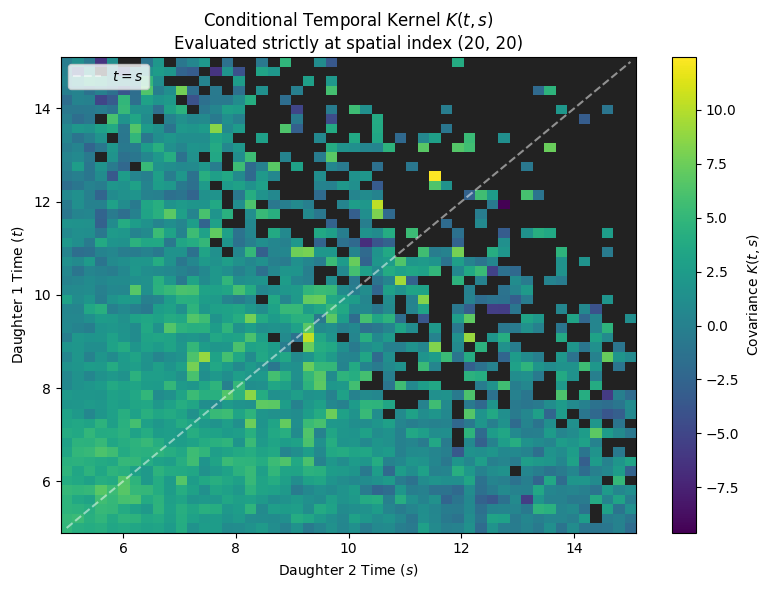

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

# 1. Simulation Parameters
# Reduced slightly to 500k to save RAM, since we are saving full history
N = 500000  
dt = 0.2
tau = 5.0    
T = 15.0     
steps_parent = int(tau / dt)
steps_daughters = int((T - tau) / dt)

beta, gamma, D_q, D_x = 0.5, 1.0, 0.5, 1.0

# 2. Discrete Grid Setup
grid_size = 40
grid_min, grid_max = -15.0, 15.0
dx = (grid_max - grid_min) / grid_size
center_idx = grid_size // 2  # The fixed spatial context for our temporal kernel

c_field = np.zeros((grid_size, grid_size))
for i in range(grid_size):
    for j in range(grid_size):
        x_val = grid_min + i * dx
        y_val = grid_min + j * dx
        c_field[i, j] = np.exp(-0.05 * (x_val**2 + y_val**2))

def get_discrete_idx(pos_array):
    idx = np.round((pos_array - grid_min) / dx)
    return np.clip(idx, 0, grid_size - 1).astype(np.int8)

def mu_func(c):
    return 15.0 * c

print(f"Running parent phase for {N} ensembles...")

X, Y, G, Q = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

for _ in range(steps_parent):
    X += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    I, J = get_discrete_idx(X), get_discrete_idx(Y)
    Q += gamma * (mu_func(c_field[I, J]) - Q) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G += (Q - beta * G) * dt

# 3. Daughter Phases (Tracking Full Spatiotemporal History)
print("Running daughter phases and recording history...")
X1, Y1, G1, Q1 = X.copy(), Y.copy(), G.copy(), Q.copy()
X2, Y2, G2, Q2 = X.copy(), Y.copy(), G.copy(), Q.copy()

# History arrays to hold the G value and spatial indices across time
G1_hist = np.zeros((N, steps_daughters), dtype=np.float32)
G2_hist = np.zeros((N, steps_daughters), dtype=np.float32)
I1_hist = np.zeros((N, steps_daughters), dtype=np.int8)
J1_hist = np.zeros((N, steps_daughters), dtype=np.int8)
I2_hist = np.zeros((N, steps_daughters), dtype=np.int8)
J2_hist = np.zeros((N, steps_daughters), dtype=np.int8)

for step in range(steps_daughters):
    # Daughter 1
    X1 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y1 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    I1, J1 = get_discrete_idx(X1), get_discrete_idx(Y1)
    Q1 += gamma * (mu_func(c_field[I1, J1]) - Q1) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G1 += (Q1 - beta * G1) * dt
    
    # Save D1 state
    G1_hist[:, step] = G1
    I1_hist[:, step] = I1
    J1_hist[:, step] = J1
    
    # Daughter 2
    X2 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y2 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    I2, J2 = get_discrete_idx(X2), get_discrete_idx(Y2)
    Q2 += gamma * (mu_func(c_field[I2, J2]) - Q2) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G2 += (Q2 - beta * G2) * dt
    
    # Save D2 state
    G2_hist[:, step] = G2
    I2_hist[:, step] = I2
    J2_hist[:, step] = J2

# 4. Compute Conditional Covariance Matrix
print(f"Filtering ensembles to compute conditional K(t, s) at discrete center...")
K_ts = np.full((steps_daughters, steps_daughters), np.nan)

for t_idx in range(steps_daughters):
    for s_idx in range(steps_daughters):
        # MASK: D1 must be at center at time t, AND D2 must be at center at time s
        mask = (I1_hist[:, t_idx] == center_idx) & (J1_hist[:, t_idx] == center_idx) & \
               (I2_hist[:, s_idx] == center_idx) & (J2_hist[:, s_idx] == center_idx)
        
        # Only compute if we have enough universes where this strict condition happened
        if np.sum(mask) > 10:
            g1_subset = G1_hist[mask, t_idx]
            g2_subset = G2_hist[mask, s_idx]
            
            K_ts[t_idx, s_idx] = np.mean(g1_subset * g2_subset) - (np.mean(g1_subset) * np.mean(g2_subset))

# 5. Plotting
plt.figure(figsize=(8, 6))
time_axis = np.linspace(tau, T, steps_daughters)

# Use pcolormesh to respect exact time bins
T_mesh, S_mesh = np.meshgrid(time_axis, time_axis)
mesh = plt.pcolormesh(S_mesh, T_mesh, K_ts, cmap='viridis', shading='nearest')

cb = plt.colorbar(mesh)
cb.set_label('Covariance $K(t, s)$')

plt.xlabel('Daughter 2 Time ($s$)')
plt.ylabel('Daughter 1 Time ($t$)')
plt.title(f'Conditional Temporal Kernel $K(t, s)$\nEvaluated strictly at spatial index ({center_idx}, {center_idx})')

plt.plot([tau, T], [tau, T], color='white', linestyle='--', alpha=0.5, label='$t=s$')
plt.legend()
# Dark background so bins missing enough pairs show up as empty space
plt.gca().set_facecolor('#222222') 

plt.tight_layout()
plt.show()

Running simulation for 1000000 universes (Full Timeline)...
Computing marginalized covariance matrix...


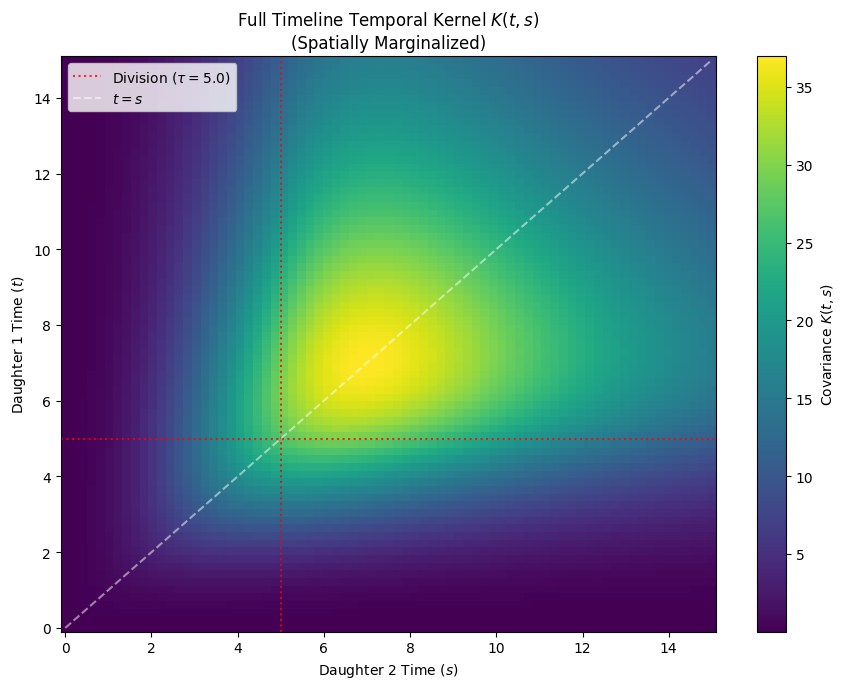

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulation Parameters
N = 1000000  
dt = 0.2
tau = 5.0    
T = 15.0     
steps_parent = int(tau / dt)
steps_daughters = int((T - tau) / dt)
steps_total = steps_parent + steps_daughters # Total steps from t=0 to T

beta, gamma, D_q, D_x = 0.5, 1.0, 0.5, 1.0

# 2. Discrete Grid Setup
grid_size = 40
grid_min, grid_max = -15.0, 15.0
dx = (grid_max - grid_min) / grid_size

c_field = np.zeros((grid_size, grid_size))
for i in range(grid_size):
    for j in range(grid_size):
        x_val = grid_min + i * dx
        y_val = grid_min + j * dx
        c_field[i, j] = np.exp(-0.05 * (x_val**2 + y_val**2))

def get_discrete_idx(pos_array):
    idx = np.round((pos_array - grid_min) / dx)
    return np.clip(idx, 0, grid_size - 1).astype(np.int8)

def mu_func(c):
    return 15.0 * c

print(f"Running simulation for {N} universes (Full Timeline)...")

# Full history arrays (from t=0 to T)
G1_hist = np.zeros((N, steps_total), dtype=np.float32)
G2_hist = np.zeros((N, steps_total), dtype=np.float32)

X, Y, G, Q = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

# 3A. Parent Phase (t=0 to tau)
for step in range(steps_parent):
    X += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    I, J = get_discrete_idx(X), get_discrete_idx(Y)
    Q += gamma * (mu_func(c_field[I, J]) - Q) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G += (Q - beta * G) * dt
    
    # Before division, the parent IS the history for both daughters
    G1_hist[:, step] = G
    G2_hist[:, step] = G

# 3B. Daughter Phases (t=tau to T)
X1, Y1, G1, Q1 = X.copy(), Y.copy(), G.copy(), Q.copy()
X2, Y2, G2, Q2 = X.copy(), Y.copy(), G.copy(), Q.copy()

for step in range(steps_daughters):
    abs_step = steps_parent + step # Map to the correct index in the total history
    
    # Daughter 1
    X1 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y1 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    C1 = c_field[get_discrete_idx(X1), get_discrete_idx(Y1)]
    Q1 += gamma * (mu_func(C1) - Q1) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G1 += (Q1 - beta * G1) * dt
    G1_hist[:, abs_step] = G1
    
    # Daughter 2
    X2 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y2 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    C2 = c_field[get_discrete_idx(X2), get_discrete_idx(Y2)]
    Q2 += gamma * (mu_func(C2) - Q2) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G2 += (Q2 - beta * G2) * dt
    G2_hist[:, abs_step] = G2

print("Computing marginalized covariance matrix...")

# 4. Compute Marginalized Covariance K(t, s) 
G1_fluc = G1_hist - np.mean(G1_hist, axis=0)
G2_fluc = G2_hist - np.mean(G2_hist, axis=0)

# Matrix multiplication does all the heavy lifting across the whole timeline
K_ts = (G1_fluc.T @ G2_fluc) / (N - 1)

# 5. Plotting
plt.figure(figsize=(9, 7))
time_axis = np.linspace(0, T, steps_total) # Axis starts at 0 now

T_mesh, S_mesh = np.meshgrid(time_axis, time_axis)
mesh = plt.pcolormesh(S_mesh, T_mesh, K_ts, cmap='viridis', shading='nearest')

cb = plt.colorbar(mesh)
cb.set_label('Covariance $K(t, s)$')

plt.xlabel('Daughter 2 Time ($s$)')
plt.ylabel('Daughter 1 Time ($t$)')
plt.title('Full Timeline Temporal Kernel $K(t, s)$\n(Spatially Marginalized)')

# Draw lines to show the quadrants clearly
plt.axvline(tau, color='red', linestyle=':', alpha=0.8, label=rf'Division ($\tau={{{tau}}}$)')
plt.axhline(tau, color='red', linestyle=':', alpha=0.8)
plt.plot([0, T], [0, T], color='white', linestyle='--', alpha=0.5, label='$t=s$')

plt.legend()
plt.tight_layout()
plt.show()

Running grid-aware vectorized simulation...
Calculating discrete exact covariance matrices...


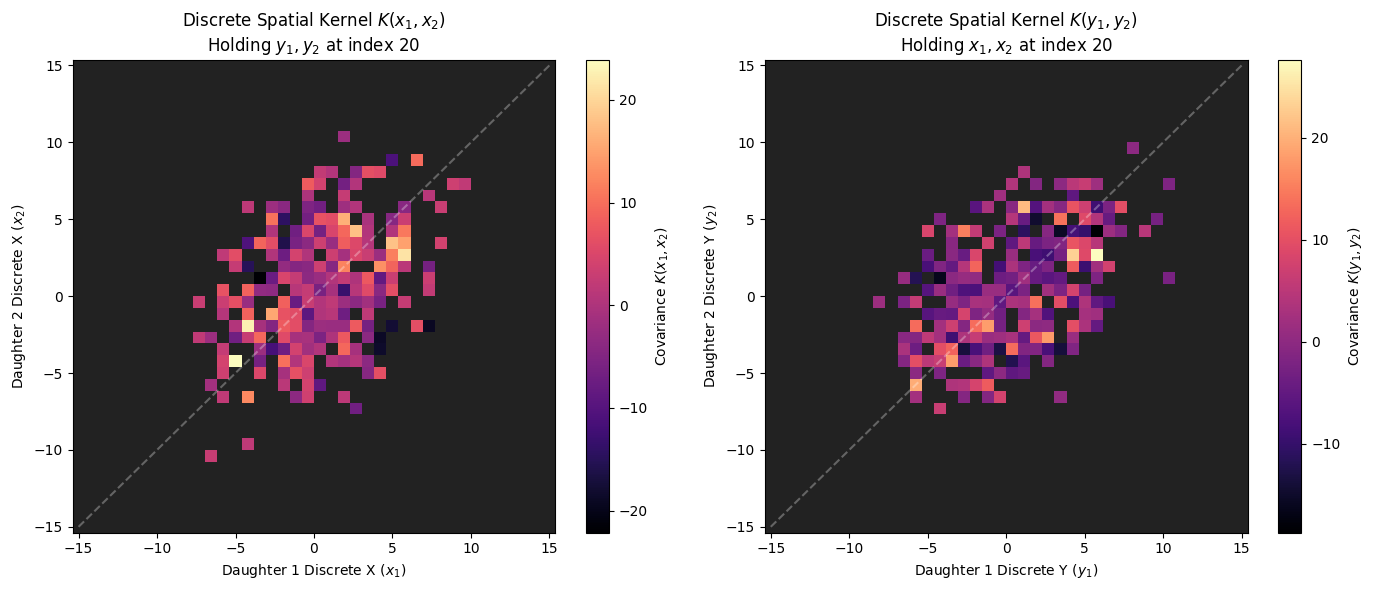

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

# 1. Simulation Parameters
N = 1000000  # 1 Million universes
dt = 0.2
tau = 5.0    
T = 15.0     
steps_parent = int(tau / dt)
steps_daughters = int((T - tau) / dt)

beta, gamma, D_q, D_x = 0.5, 1.0, 0.5, 1.0

# 2. Explicit Discrete Grid Setup (The Smart Way!)
grid_size = 40
grid_min, grid_max = -15.0, 15.0
dx = (grid_max - grid_min) / grid_size
center_idx = grid_size // 2  # The index for holding a dimension constant (approx 0)

# Pre-compute the discrete concentration field to make lookups blazing fast
c_field = np.zeros((grid_size, grid_size))
for i in range(grid_size):
    for j in range(grid_size):
        x_val = grid_min + i * dx
        y_val = grid_min + j * dx
        c_field[i, j] = np.exp(-0.05 * (x_val**2 + y_val**2))

def get_discrete_idx(pos_array):
    """Maps continuous positions perfectly to our discrete grid indices."""
    idx = np.round((pos_array - grid_min) / dx)
    return np.clip(idx, 0, grid_size - 1).astype(int)

def mu_func(c):
    return 15.0 * c

print("Running grid-aware vectorized simulation...")

# 3. Parent Phase
X, Y, G, Q = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

for _ in range(steps_parent):
    X += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    I = get_discrete_idx(X)
    J = get_discrete_idx(Y)
    C_local = c_field[I, J]  # Exact discrete lookup!
    Q += gamma * (mu_func(C_local) - Q) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G += (Q - beta * G) * dt

# 4. Daughter Phases
X1, Y1, G1, Q1 = X.copy(), Y.copy(), G.copy(), Q.copy()
X2, Y2, G2, Q2 = X.copy(), Y.copy(), G.copy(), Q.copy()

for _ in range(steps_daughters):
    # Daughter 1
    X1 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y1 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    C1 = c_field[get_discrete_idx(X1), get_discrete_idx(Y1)]
    Q1 += gamma * (mu_func(C1) - Q1) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G1 += (Q1 - beta * G1) * dt
    
    # Daughter 2
    X2 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y2 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    C2 = c_field[get_discrete_idx(X2), get_discrete_idx(Y2)]
    Q2 += gamma * (mu_func(C2) - Q2) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G2 += (Q2 - beta * G2) * dt

print("Calculating discrete exact covariance matrices...")

# Get final discrete indices
I1, J1 = get_discrete_idx(X1), get_discrete_idx(Y1)
I2, J2 = get_discrete_idx(X2), get_discrete_idx(Y2)

# 5. Populate the exact Discrete Covariance Matrices
def compute_discrete_kernel(idx1, idx2, mask):
    """Calculates exactly E[G1*G2] - E[G1]*E[G2] across discrete indices."""
    K = np.full((grid_size, grid_size), np.nan)
    
    # Only look at universes that fit our slice criteria
    valid_idx1 = idx1[mask]
    valid_idx2 = idx2[mask]
    valid_g1 = G1[mask]
    valid_g2 = G2[mask]
    
    # We populate the discrete i, j combinations directly
    for i in range(grid_size):
        for j in range(grid_size):
            # Find universes where Daughter 1 is at index i and Daughter 2 is at index j
            pair_mask = (valid_idx1 == i) & (valid_idx2 == j)
            if np.sum(pair_mask) > 5:  # Require at least a few samples to avoid wild noise
                g1_vals = valid_g1[pair_mask]
                g2_vals = valid_g2[pair_mask]
                K[i, j] = np.mean(g1_vals * g2_vals) - (np.mean(g1_vals) * np.mean(g2_vals))
                
    return K

# Hold Y constant (at the center discrete index) to map X covariance
mask_y = (J1 == center_idx) & (J2 == center_idx)
K_x = compute_discrete_kernel(I1, I2, mask_y)

# Hold X constant (at the center discrete index) to map Y covariance
mask_x = (I1 == center_idx) & (I2 == center_idx)
K_y = compute_discrete_kernel(J1, J2, mask_x)

# 6. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Map indices back to spatial coordinates for the axis labels
grid_coords = np.linspace(grid_min, grid_max, grid_size)
X_mesh, Y_mesh = np.meshgrid(grid_coords, grid_coords)

mesh1 = axes[0].pcolormesh(X_mesh, Y_mesh, K_x.T, cmap='magma', shading='nearest')
fig.colorbar(mesh1, ax=axes[0], label='Covariance $K(x_1, x_2)$')
axes[0].set_title('Discrete Spatial Kernel $K(x_1, x_2)$\nHolding $y_1, y_2$ at index ' + str(center_idx))
axes[0].set_xlabel('Daughter 1 Discrete X ($x_1$)')
axes[0].set_ylabel('Daughter 2 Discrete X ($x_2$)')
axes[0].plot([grid_min, grid_max], [grid_min, grid_max], 'w--', alpha=0.3)
axes[0].set_facecolor('#222222') # Dark background for nulls

mesh2 = axes[1].pcolormesh(X_mesh, Y_mesh, K_y.T, cmap='magma', shading='nearest')
fig.colorbar(mesh2, ax=axes[1], label='Covariance $K(y_1, y_2)$')
axes[1].set_title('Discrete Spatial Kernel $K(y_1, y_2)$\nHolding $x_1, x_2$ at index ' + str(center_idx))
axes[1].set_xlabel('Daughter 1 Discrete Y ($y_1$)')
axes[1].set_ylabel('Daughter 2 Discrete Y ($y_2$)')
axes[1].plot([grid_min, grid_max], [grid_min, grid_max], 'w--', alpha=0.3)
axes[1].set_facecolor('#222222')

plt.tight_layout()
plt.show()

Running parent phase...
Running daughter phases and building spatiotemporal history...
Computing fully marginalized spatial kernels using fast bincounting...


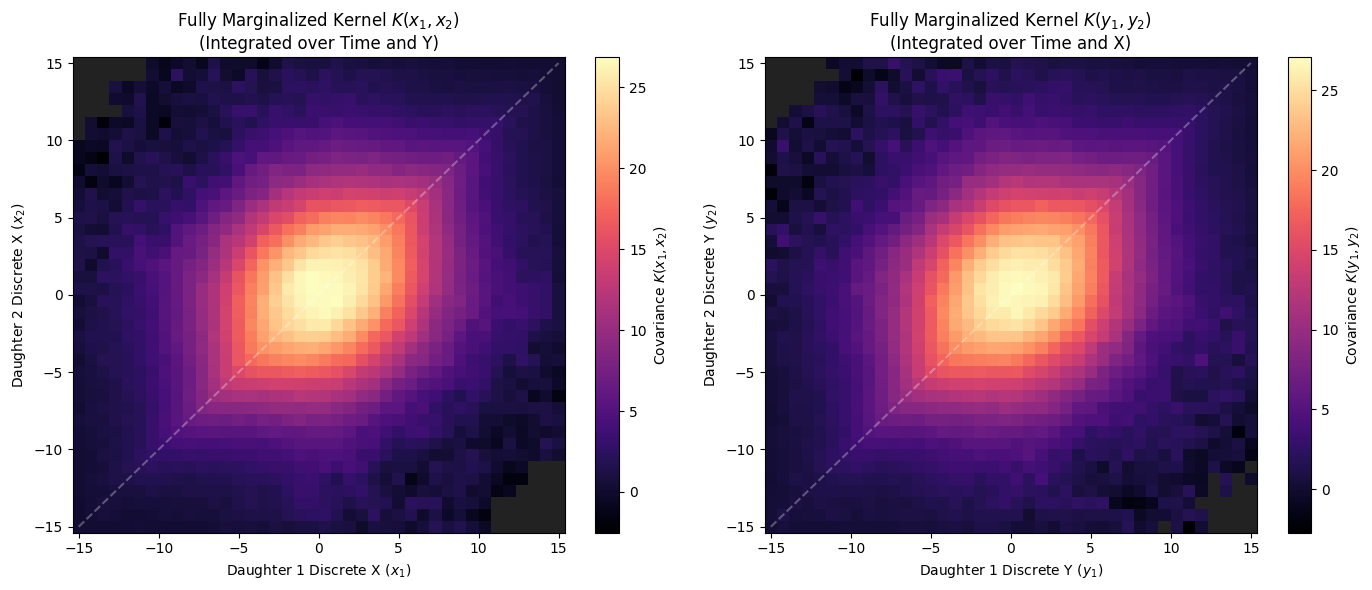

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

# 1. Simulation Parameters
N = 500000   # 500k universes
dt = 0.2
tau = 5.0    
T = 15.0     
steps_parent = int(tau / dt)
steps_daughters = int((T - tau) / dt)

beta, gamma, D_q, D_x = 0.5, 1.0, 0.5, 1.0

# 2. Discrete Grid Setup
grid_size = 40
grid_min, grid_max = -15.0, 15.0
dx = (grid_max - grid_min) / grid_size

c_field = np.zeros((grid_size, grid_size))
for i in range(grid_size):
    for j in range(grid_size):
        x_val = grid_min + i * dx
        y_val = grid_min + j * dx
        c_field[i, j] = np.exp(-0.05 * (x_val**2 + y_val**2))

def get_discrete_idx(pos_array):
    idx = np.round((pos_array - grid_min) / dx)
    return np.clip(idx, 0, grid_size - 1).astype(np.int64) # int64 for large flat indices later

def mu_func(c):
    return 15.0 * c

print("Running parent phase...")

X, Y, G, Q = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)

for _ in range(steps_parent):
    X += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    I, J = get_discrete_idx(X), get_discrete_idx(Y)
    Q += gamma * (mu_func(c_field[I, J]) - Q) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G += (Q - beta * G) * dt

# 3. Daughter Phases (Tracking Spatial History)
print("Running daughter phases and building spatiotemporal history...")
X1, Y1, G1, Q1 = X.copy(), Y.copy(), G.copy(), Q.copy()
X2, Y2, G2, Q2 = X.copy(), Y.copy(), G.copy(), Q.copy()

# History arrays for the daughter phase
G1_hist = np.zeros((N, steps_daughters), dtype=np.float32)
G2_hist = np.zeros((N, steps_daughters), dtype=np.float32)
I1_hist = np.zeros((N, steps_daughters), dtype=np.int64)
J1_hist = np.zeros((N, steps_daughters), dtype=np.int64)
I2_hist = np.zeros((N, steps_daughters), dtype=np.int64)
J2_hist = np.zeros((N, steps_daughters), dtype=np.int64)

for step in range(steps_daughters):
    # Daughter 1
    X1 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y1 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    I1, J1 = get_discrete_idx(X1), get_discrete_idx(Y1)
    Q1 += gamma * (mu_func(c_field[I1, J1]) - Q1) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G1 += (Q1 - beta * G1) * dt
    G1_hist[:, step], I1_hist[:, step], J1_hist[:, step] = G1, I1, J1
    
    # Daughter 2
    X2 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    Y2 += np.sqrt(2 * D_x * dt) * np.random.randn(N)
    I2, J2 = get_discrete_idx(X2), get_discrete_idx(Y2)
    Q2 += gamma * (mu_func(c_field[I2, J2]) - Q2) * dt + np.sqrt(2 * D_q * dt) * np.random.randn(N)
    G2 += (Q2 - beta * G2) * dt
    G2_hist[:, step], I2_hist[:, step], J2_hist[:, step] = G2, I2, J2

print("Computing fully marginalized spatial kernels using fast bincounting...")

# 4. Fast Marginalization Magic
def fast_marginalized_covariance(idx1, idx2, g1, g2):
    """Computes full covariance matrix across millions of flattened states instantly."""
    # Flatten all time steps and universes into 1D arrays (~25 million points)
    idx1_flat, idx2_flat = idx1.flatten(), idx2.flatten()
    g1_flat, g2_flat = g1.flatten(), g2.flatten()
    
    # Map 2D grid combinations (i, j) to a single 1D index
    flat_indices = idx1_flat * grid_size + idx2_flat
    
    # Fast accumulations
    counts = np.bincount(flat_indices, minlength=grid_size**2)
    sum_g1 = np.bincount(flat_indices, weights=g1_flat, minlength=grid_size**2)
    sum_g2 = np.bincount(flat_indices, weights=g2_flat, minlength=grid_size**2)
    sum_g1g2 = np.bincount(flat_indices, weights=g1_flat * g2_flat, minlength=grid_size**2)
    
    # Avoid divide-by-zero for grid combinations that rarely/never happened
    valid = counts > 5
    K_flat = np.full(grid_size**2, np.nan)
    
    # E[G1*G2] - E[G1]*E[G2]
    E_g1 = sum_g1[valid] / counts[valid]
    E_g2 = sum_g2[valid] / counts[valid]
    E_g1g2 = sum_g1g2[valid] / counts[valid]
    K_flat[valid] = E_g1g2 - (E_g1 * E_g2)
    
    # Reshape back to the 2D grid
    return K_flat.reshape((grid_size, grid_size))

# Calculate K_x (Marginalized over Time and Y)
K_x = fast_marginalized_covariance(I1_hist, I2_hist, G1_hist, G2_hist)

# Calculate K_y (Marginalized over Time and X)
K_y = fast_marginalized_covariance(J1_hist, J2_hist, G1_hist, G2_hist)

# 5. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

grid_coords = np.linspace(grid_min, grid_max, grid_size)
X_mesh, Y_mesh = np.meshgrid(grid_coords, grid_coords)

# X Kernel
mesh1 = axes[0].pcolormesh(X_mesh, Y_mesh, K_x.T, cmap='magma', shading='nearest')
fig.colorbar(mesh1, ax=axes[0], label='Covariance $K(x_1, x_2)$')
axes[0].set_title('Fully Marginalized Kernel $K(x_1, x_2)$\n(Integrated over Time and Y)')
axes[0].set_xlabel('Daughter 1 Discrete X ($x_1$)')
axes[0].set_ylabel('Daughter 2 Discrete X ($x_2$)')
axes[0].plot([grid_min, grid_max], [grid_min, grid_max], 'w--', alpha=0.3)
axes[0].set_facecolor('#222222')

# Y Kernel
mesh2 = axes[1].pcolormesh(X_mesh, Y_mesh, K_y.T, cmap='magma', shading='nearest')
fig.colorbar(mesh2, ax=axes[1], label='Covariance $K(y_1, y_2)$')
axes[1].set_title('Fully Marginalized Kernel $K(y_1, y_2)$\n(Integrated over Time and X)')
axes[1].set_xlabel('Daughter 1 Discrete Y ($y_1$)')
axes[1].set_ylabel('Daughter 2 Discrete Y ($y_2$)')
axes[1].plot([grid_min, grid_max], [grid_min, grid_max], 'w--', alpha=0.3)
axes[1].set_facecolor('#222222')

plt.tight_layout()
plt.show()

**But what if our cells interacted?**

<!-- ## Coupled Stochastic Production with Spatial Diffusion

This is a beautiful model. The new term introduces **spatial coupling** — each cell's production rate is nudged toward its neighbors', weighted by inverse squared distance. Let's unpack the structure.

---

## Rewriting the SDE

$$dq_i = -\gamma q_i\, dt + \gamma\mu_i\, dt + \eta \sum_{j \neq i} \frac{q_j - q_i}{|\vec{p}_j - \vec{p}_i|^2}\, dt + \sqrt{2D}\, dW_t^{(i)}$$

Define the **spatial coupling matrix** $L$ with entries:

$$L_{ij} = \begin{cases} \displaystyle\frac{1}{|\vec{p}_j - \vec{p}_i|^2} & i \neq j \\[6pt] \displaystyle-\sum_{k \neq i} \frac{1}{|\vec{p}_k - \vec{p}_i|^2} & i = j \end{cases}$$

Then the coupling term is exactly $\eta (L\mathbf{q})_i$, and the **vector SDE** becomes:

$$\boxed{d\mathbf{q} = \left[-\gamma \mathbf{q} + \gamma\boldsymbol{\mu} + \eta L\mathbf{q}\right]dt + \sqrt{2D}\, d\mathbf{W}_t}$$

$$= \left[({\eta L - \gamma I})\mathbf{q} + \gamma\boldsymbol{\mu}\right]dt + \sqrt{2D}\, d\mathbf{W}_t$$

---

## The Matrix $L$ is a Graph Laplacian

This is precisely a **weighted graph Laplacian** on the cell positions, with edge weights $w_{ij} = 1/|\vec{p}_j - \vec{p}_i|^2$. Key properties:

- $L$ is **symmetric** and **negative semi-definite**
- $L\mathbf{1} = 0$ — uniform $\mathbf{q}$ is in the null space
- Eigenvalues $0 = \lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_N$
- The coupling **penalizes gradients** in $q$ across space — it's a discrete diffusion operator

So the system is a **stochastic reaction-diffusion equation** on a point cloud.

---

## Stability Analysis

The drift matrix is $A = \eta L - \gamma I$. Stability requires all eigenvalues of $A$ to have negative real part.

Since $L$'s eigenvalues $\lambda_k \leq 0$:

$$\text{eig}(A) = \eta\lambda_k - \gamma$$

The most dangerous mode is $\lambda_1 = 0$ (the uniform mode), giving:

$$\text{eig}(A)_{\text{max}} = -\gamma < 0$$

So the system is **always stable** for $\gamma > 0$, regardless of $\eta > 0$. The coupling only **accelerates relaxation** of spatial gradients without destabilizing the system.

---

## Diagonalization — Normal Modes

Let $L = V\Lambda V^\top$ be the eigendecomposition. Transform to **normal coordinates** $\tilde{\mathbf{q}} = V^\top \mathbf{q}$:

$$d\tilde{q}_k = (\eta\lambda_k - \gamma)\tilde{q}_k\, dt + \gamma\tilde{\mu}_k\, dt + \sqrt{2D}\, d\tilde{W}_t^{(k)}$$

where $\tilde{\boldsymbol{\mu}} = V^\top \boldsymbol{\mu}$. Each mode decouples into an **Ornstein-Uhlenbeck process**:

$$d\tilde{q}_k = -\underbrace{(\gamma - \eta\lambda_k)}_{\gamma_k}\tilde{q}_k\, dt + \gamma\tilde{\mu}_k\, dt + \sqrt{2D}\, d\tilde{W}_t^{(k)}$$

with effective decay rate $\gamma_k = \gamma - \eta\lambda_k \geq \gamma > 0$.

---

## Solution via OU Theory

Each mode has the exact solution:

$$\tilde{q}_k(t) = e^{-\gamma_k t}\tilde{q}_k(0) + \gamma\int_0^t e^{-\gamma_k(t-u)}\tilde{\mu}_k(u)\, du + \sqrt{2D}\int_0^t e^{-\gamma_k(t-u)}\, d\tilde{W}_u^{(k)}$$

The **steady-state variance** of each mode (from the OU fluctuation-dissipation result):

$$\text{Var}(\tilde{q}_k^\infty) = \frac{D}{\gamma_k} = \frac{D}{\gamma - \eta\lambda_k}$$

Since $\lambda_k \leq 0$, higher spatial frequency modes ($|\lambda_k|$ large) have **smaller variance** — the coupling suppresses spatial fluctuations, acting like a smoothing filter.

---

## Continuum Limit

If cells are dense on a 2D domain, $L$ approximates a continuous operator. The coupling term:

$$\eta \sum_{j\neq i} \frac{q_j - q_i}{|\vec{p}_j - \vec{p}_i|^2}$$

converges (with appropriate normalization) to a **fractional Laplacian** $\eta(-\Delta)^{s} q$ with $s \to 0$ in 2D, or more precisely to an **integral operator** of the form:

$$\mathcal{L}q(\vec{p}) = \eta \int \frac{q(\vec{p}\,') - q(\vec{p})}{|\vec{p}\,' - \vec{p}|^2} d\vec{p}\,'$$

which is the generator of a **2D Cauchy (Lévy) process** — a non-local diffusion. The full continuum SPDE becomes:

$$dq = \left[-\gamma q + \gamma\mu(c(\vec{p})) + \eta\mathcal{L}q\right]dt + \sqrt{2D}\, dW(\vec{p}, t)$$

This is a **stochastic fractional reaction-diffusion equation**.

---

## Summary

| Feature | Interpretation |
|---|---|
| $\eta L\mathbf{q}$ | Discrete graph Laplacian — spatial smoothing of $q$ |
| Stability | Always stable for $\gamma > 0$; coupling only helps |
| Normal modes | Decouple into independent OU processes with rate $\gamma_k = \gamma - \eta\lambda_k$ |
| Steady-state variance | $D/\gamma_k$ — high-frequency spatial modes are suppressed |
| Continuum limit | Fractional/nonlocal Laplacian SPDE |
| Physical picture | Cells collectively coordinate production via a **spatial consensus mechanism** |

The key physical insight is that $\eta$ controls the **coherence length** of production rate fluctuations — large $\eta$ forces neighboring cells to synchronize their $q_i$ values, smoothing out spatial heterogeneity driven by $\mu$ and the noise $dW$. -->